# Audio Search with audio embeddings and QDRANTh - Human voices 

## Executive Summary

This notebook demonstrates how to perform **voice similarity search** using:

- **Speaker embeddings** generated by the SpeechBrain ECAPA-VOXCELEB model: https://huggingface.co/speechbrain/spkrec-ecapa-voxceleb
- **Qdrant capabilities**
- A collection of human voice recordings stored locally

The goal is to find audio files with similar speakers by converting voice recordings into high-dimensional vectors (embeddings) and storing them in an Qdrant vector index.

## Architecture

```text
Audio Files
     ↓
SpeechBrain Speaker Embedding Model
     ↓
Voice Embeddings (Vectors)
     ↓
Qdrant Vector Index
     ↓
Similarity Search
     ↓
Most Similar Voices Returned
```

The notebook uses the model:

- `speechbrain/spkrec-ecapa-voxceleb`
> https://huggingface.co/speechbrain/spkrec-ecapa-voxceleb

for generating speaker embeddings from audio samples.

## Main Components

### 1. Environment Setup

The notebook imports:

- Audio processing libraries: `librosa`, `soundfile`
- Data science tools: `numpy`, `pandas`, `matplotlib`
- Qdrant SDKs
- Vector-search configuration classes for Azure AI Search

### 2. Configuration

Key settings defined in the notebook:

- Search index
- Audio directory: `voices`
- Standard sampling rate: `16000 Hz`

### 3. Audio Metadata Analysis

A helper function extracts:

- Audio format
- Bit depth
- Bitrate
- Sample rate
- Number of channels
- Duration
- File size
- Creation and modification dates

### 4. Audio Visualization

The notebook includes waveform visualization using:
- `librosa`
- `matplotlib`

This displays the amplitude over time for a selected audio file.

## Qdrant Search informations

For the Audio Search human voices voice-search project, Qdrant would act as a dedicated speaker-embedding database and nearest-neighbor search engine. The biggest advantages are open-source deployment, local/on-prem support, vector-first design, and potentially richer multivector speaker representations. Azure AI Search remains stronger when you need broader enterprise search, semantic ranking, and integration with the Azure RAG ecosystem.

## Potential Use Cases

This notebook can serve as a foundation for:

- Speaker identification
- Audio archive search
- Call-center voice matching
- Forensic voice analysis
- Media content discovery
- Voice biometric applications

## Executive One-Liner

**This notebook builds a voice-search solution that converts human speech recordings into speaker embeddings using SpeechBrain and performs similarity search through Qdrant vector indexes.**


> Serge Retkowsky - serge.retkowsky@microsoft.com - September 2026


In [1]:
import ast
import io
import json
import librosa
import matplotlib.pyplot as plt
import numpy as np
import os
import os.path
import pandas as pd
import plotly.express as px
import plotly.io as pio
import re
import soundfile as sf
import sys
import torch
import time
import uuid
import umap

from __future__ import annotations
from IPython.display import display, FileLink, Audio
from dataclasses import dataclass
from dotenv import load_dotenv
from pandas.io.formats.style import Styler
from pathlib import Path
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance,
    FieldCondition,
    Filter,
    HnswConfigDiff,
    MatchValue,
    OptimizersConfigDiff,
    PayloadSchemaType,
    PointStruct,
    QuantizationSearchParams,
    ScalarQuantization,
    ScalarQuantizationConfig,
    ScalarType,
    SearchParams,
    VectorParams,
)
from speechbrain.inference.speaker import EncoderClassifier
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
from typing import Any, Dict, List, Optional, Sequence

In [2]:
#%pip install qdrant-client

## 1. Settings

In [3]:
sys.version

'3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]'

In [4]:
# Qdrant index name
DEFAULT_LOCATION = "./qdrant_data"
INDEX_NAME = "audio-voices-qdrant-index"
QDRANT_PATH = Path(os.path.expanduser("~")) / "qdrant_data"
EMB_LENGTH = 192  # ECAPA-TDNN embedding dimension

sr = 16000  # Sampling rate for all voice audio files

In [5]:
AUDIO_DIR = "voices"

## 2. Helper

In [6]:
def get_client(location: str = DEFAULT_LOCATION) -> QdrantClient:
    """
    Create a Qdrant client, either embedded or connected to a server.
 
    Args:
        location: Local directory path for embedded mode, ':memory:' for a
            volatile in-process store, or an http(s) URL for server mode.
 
    Returns:
        A configured QdrantClient instance.
    """
    if location.startswith("http://") or location.startswith("https://"):
        return QdrantClient(url=location)

    if location == ":memory:":
        return QdrantClient(location=":memory:")

    return QdrantClient(path=location)

In [7]:
def delete_index_if_exists(client: QdrantClient, index_name: str) -> None:
    """
    Delete a Qdrant collection if it exists.
 
    Args:
        client: An active Qdrant client.
        index_name: Name of the collection to drop.
 
    Returns:
        None.
    """
    if client.collection_exists(index_name):
        client.delete_collection(index_name)
        print(f"Existing collection '{index_name}' deleted.")
    else:
        print(f"Collection '{index_name}' did not exist, nothing to delete.")

In [8]:
def _to_point_id(raw_id: str) -> Any:
    """
    Convert an arbitrary string identifier into a valid Qdrant point id.
 
    Qdrant accepts unsigned integers or UUIDs only.
 
    Args:
        raw_id: The source identifier, for example '42' or a file name.
 
    Returns:
        An int when the input is numeric, otherwise a deterministic UUID string.
    """
    if raw_id.isdigit():
        return int(raw_id)

    return str(uuid.uuid5(uuid.NAMESPACE_URL, raw_id))

In [9]:
def upload_documents_to_index(
    client: QdrantClient,
    index_name: str,
    documents: List[Dict[str, Any]],
    batch_size: int = 256,
) -> None:
    """
    Upsert documents into a Qdrant collection in batches.
 
    Args:
        client: An active Qdrant client.
        index_name: Target collection name.
        documents: Raw document dicts to normalize and upload.
        batch_size: Number of points sent per request.
 
    Returns:
        None.
    """
    points = [normalize_document(doc) for doc in documents]

    for start in range(0, len(points), batch_size):
        client.upsert(
            collection_name=index_name,
            points=points[start:start + batch_size],
            wait=True,
        )

    print(f"Uploaded {len(points)} points into '{index_name}'.")

In [10]:
def print_index_summary(client: QdrantClient, index_name: str) -> None:
    """
    Print a readable summary of a collection configuration.
 
    Args:
        client: An active Qdrant client.
        index_name: Collection to summarize.
 
    Returns:
        None. Writes to stdout.
    """
    info = client.get_collection(index_name)
    vectors = info.config.params.vectors
    hnsw = info.config.hnsw_config

    print(f"Collection name: {index_name}")
    print(f"Points count:    {info.points_count}")
    print(f"Status:          {info.status}")
    print("\nVector config:")
    print(f"  Dimension: {vectors.size}")
    print(f"  Distance:  {vectors.distance}")
    print("\nHNSW config:")
    print(f"  m:           {hnsw.m}")
    print(f"  ef_construct: {hnsw.ef_construct}")
    print(f"\nQuantization: {info.config.quantization_config}")
    print(f"\nPayload indexes: {list(info.payload_schema.keys())}")

In [11]:
def get_index_document_count(client: QdrantClient, index_name: str) -> int:
    """
    Return the number of points stored in a collection.
 
    Args:
        client: An active Qdrant client.
        index_name: Collection to inspect.
 
    Returns:
        The point count.
    """
    return client.count(collection_name=index_name, exact=True).count

In [12]:
def colored_similarity(value: float) -> str:
    """
    Format a similarity score as a colored string based on thresholds.

    Args:
        value: The similarity score, typically between 0.0 and 1.0.

    Returns:
        The formatted string with ANSI color codes applied.
    """
    green = "\033[92m"
    orange = "\033[38;5;208m"
    red = "\033[91m"
    reset = "\033[0m"

    if value > 0.7:
        color = green
    elif value >= 0.5:
        color = orange
    else:
        color = red

    return f"{color}{value:.4f}{reset}"

In [13]:
def normalize_document(doc: Dict[str, Any]) -> PointStruct:
    """
    Turn a raw document dict into a Qdrant point.
 
    Flattens a nested embedding and moves every non vector field into the
    payload, which keeps all metadata filterable.
 
    Args:
        doc: Raw document holding at least id_audiofile, audio_filename and
            audio_embeddings.
 
    Returns:
        A PointStruct ready to be upserted.
    """
    embeddings = doc["audio_embeddings"]
    if len(embeddings) == 1 and isinstance(embeddings[0], list):
        embeddings = embeddings[0]

    payload = {
        key: value
        for key, value in doc.items()
        if key not in ("audio_embeddings", "id_audiofile")
    }
    payload.setdefault(
        "speaker_id",
        str(doc.get("audio_filename", "")).split("_segment_")[0],
    )

    return PointStruct(
        id=_to_point_id(str(doc["id_audiofile"])),
        vector=[float(v) for v in embeddings],
        payload=payload,
    )

In [14]:
def build_documents(
    file_paths: List[str],
    category: str,
    sample_rate: int = 16000,
) -> List[Dict[str, Any]]:
    """
    Compute one speaker embedding per audio file and wrap it into a document.

    Args:
        file_paths: Absolute or relative paths to the audio files.
        category: Free text label stored in the payload, for example 'enrollment'.
        sample_rate: Target sample rate expected by get_voice_embedding.

    Returns:
        A list of document dicts ready for upload_documents_to_index.
    """
    documents: List[Dict[str, Any]] = []

    for idx, file_path in enumerate(tqdm(file_paths, desc="Embedding"),
                                    start=1):
        audio_numpy, sr = librosa.load(file_path, sr=sample_rate)
        embedding = get_voice_embedding(audio_numpy, sr)
        vector = np.asarray(embedding, dtype=np.float32).ravel()

        stem = Path(file_path).stem
        documents.append({
            "id_audiofile": str(idx),
            "audio_filename": Path(file_path).name,
            "audio_filepath": str(file_path),
            "audio_category": category,
            "speaker_id": stem.split("_segment_")[0],
            "audio_embeddings": vector.tolist(),
        })

    return documents

In [15]:
def create_audio_search_index(
    client: QdrantClient,
    index_name: str,
    emb_length: int,
    hnsw_m: int = 16,
    hnsw_ef_construct: int = 400,
    enable_quantization: bool = False,
    payload_index_fields: Optional[Sequence[str]] = None,
) -> None:
    """
    Create a Qdrant collection for speaker embeddings with HNSW indexing.
 
    Args:
        client: An active Qdrant client.
        index_name: Name of the collection to create.
        emb_length: Dimension of the speaker embeddings (192 for ECAPA-TDNN).
        hnsw_m: Number of bi-directional links per node in the HNSW graph.
        hnsw_ef_construct: Size of the dynamic candidate list at build time.
        enable_quantization: Apply int8 scalar quantization to reduce the
            memory footprint at large scale.
        payload_index_fields: Keyword payload fields to index for fast
            filtering. Defaults to speaker_id, audio_category and language.
 
    Returns:
        None.
    """
    quantization = None
    if enable_quantization:
        quantization = ScalarQuantization(scalar=ScalarQuantizationConfig(
            type=ScalarType.INT8,
            quantile=0.99,
            always_ram=True,
        ))

    client.create_collection(
        collection_name=index_name,
        vectors_config=VectorParams(
            size=emb_length,
            distance=Distance.COSINE,
            on_disk=False,
        ),
        hnsw_config=HnswConfigDiff(m=hnsw_m, ef_construct=hnsw_ef_construct),
        optimizers_config=OptimizersConfigDiff(default_segment_number=2),
        quantization_config=quantization,
    )

    fields = payload_index_fields
    if fields is None:
        fields = ("speaker_id", "audio_category", "language")

    for field_name in fields:
        client.create_payload_index(
            collection_name=index_name,
            field_name=field_name,
            field_schema=PayloadSchemaType.KEYWORD,
        )

    print(f"Collection '{index_name}' created with dim={emb_length}.")

In [16]:
@dataclass(frozen=True)
class VoiceMatch:
    """A single nearest neighbor returned by the vector search."""

    audio_filename: str
    speaker_id: str
    score: float
    payload: Dict[str, Any]


def search_embedding(
    client: QdrantClient,
    index_name: str,
    embedding: np.ndarray,
    topn: int = 10,
    score_threshold: Optional[float] = None,
    payload_filter: Optional[Dict[str, str]] = None,
    exhaustive: bool = False,
    hnsw_ef: int = 128,
) -> List[VoiceMatch]:
    """
    Run a cosine nearest neighbor search against the collection.
 
    Args:
        client: An active Qdrant client.
        index_name: Collection to query.
        embedding: Query speaker embedding, 1D array.
        topn: Number of neighbors to retrieve.
        score_threshold: Minimum cosine similarity. Results below are dropped,
            which implements open set rejection of unknown speakers.
        payload_filter: Optional exact match filter, for example
            {'audio_category': 'radio'}.
        exhaustive: Bypass HNSW and run a brute force scan. Useful as recall
            ground truth when benchmarking the approximate index.
        hnsw_ef: Size of the dynamic candidate list at query time. Higher
            values improve recall at the cost of latency.
 
    Returns:
        A list of VoiceMatch sorted by decreasing cosine similarity.
    """
    query_filter = None
    if payload_filter:
        query_filter = Filter(must=[
            FieldCondition(key=key, match=MatchValue(value=value))
            for key, value in payload_filter.items()
        ])

    hits = client.query_points(
        collection_name=index_name,
        query=np.asarray(embedding, dtype=np.float32).ravel().tolist(),
        limit=topn,
        score_threshold=score_threshold,
        query_filter=query_filter,
        with_payload=True,
        search_params=SearchParams(
            hnsw_ef=hnsw_ef,
            exact=exhaustive,
            quantization=QuantizationSearchParams(rescore=True),
        ),
    ).points

    return [
        VoiceMatch(
            audio_filename=hit.payload.get("audio_filename", ""),
            speaker_id=hit.payload.get("speaker_id", ""),
            score=float(hit.score),
            payload=hit.payload,
        ) for hit in hits
    ]

In [17]:
def plot_umap_3d(
    df: pd.DataFrame,
    coords: np.ndarray,
    label_col: str = "speaker",
    hover_col: str = "audio_filename",
    show_text: bool = False,
) -> "px.scatter_3d":
    """Interactive 3D UMAP scatter plot built with Plotly, without legend.

    Args:
        df: DataFrame containing the label and hover columns.
        coords: 3D UMAP coordinates aligned with df rows.
        label_col: Column used to color the points.
        hover_col: Column shown on hover and as static text if show_text is True.
        show_text: Display the labels permanently instead of on hover only.

    Returns:
        The Plotly figure, already displayed.
    """
    plot_df = df.copy()
    plot_df[["umap_x", "umap_y", "umap_z"]] = coords
    plot_df["label"] = plot_df[hover_col].astype(str).str.replace(".wav",
                                                                  "",
                                                                  regex=False)

    fig = px.scatter_3d(
        plot_df,
        x="umap_x",
        y="umap_y",
        z="umap_z",
        color=label_col,
        text="label" if show_text else None,
        hover_data={
            "label": True,
            "umap_x": ":.2f",
            "umap_y": ":.2f",
            "umap_z": ":.2f"
        },
        title="UMAP 3D projection of audio embeddings",
    )
    fig.update_traces(marker=dict(size=5, opacity=0.85),
                      textposition="top center")
    fig.update_layout(
        height=750,
        showlegend=False,
        scene=dict(xaxis_title="UMAP 1",
                   yaxis_title="UMAP 2",
                   zaxis_title="UMAP 3"),
    )
    fig.show()
    return fig

In [18]:
def get_voice_embedding(audio_numpy: np.ndarray,
                        sample_rate: int = 16000) -> np.ndarray:
    """
    Compute a speaker embedding from a numpy audio array using ECAPA-TDNN.

    Args:
        audio_numpy: 1D numpy array containing the audio waveform.
        sample_rate: Sample rate of the input audio. ECAPA-TDNN expects 16000 Hz.

    Returns:
        A 1D numpy array containing the speaker embedding vector.
    """
    if sample_rate != sr:
        raise ValueError(
            f"Expected 16000 Hz audio, got {sample_rate} Hz. Resample first.")

    audio_tensor: torch.Tensor = torch.from_numpy(
        audio_numpy).float().unsqueeze(0)
    embedding: torch.Tensor = classifier.encode_batch(audio_tensor)

    return embedding.squeeze().detach().numpy()

In [19]:
def get_audio_metadata(audio_file):
    """
    Audio metadata generation from an audio file
    """
    import audio_metadata

    audiofilemetadata = audio_metadata.load(audio_file)
    audio_format = audiofilemetadata.streaminfo.audio_format
    bit_depth = audiofilemetadata.streaminfo.bit_depth
    bitrate = audiofilemetadata.streaminfo.bitrate
    nb_channels = audiofilemetadata.streaminfo.channels
    duration = audiofilemetadata.streaminfo.duration
    sample_rate = audiofilemetadata.streaminfo.sample_rate
    audio_filesize = audiofilemetadata.filesize
    last_modified_date = time.ctime(os.path.getmtime(audio_file))
    creation_date = time.ctime(os.path.getctime(audio_file))

    print("\n", "-" * 20, "Audio Statistics", "-" * 20, "\n")
    print("Audio File:\t", audio_file)
    print("Modified Date:\t", last_modified_date)
    print("Creation Date:\t", creation_date)
    print("File Size:\t", audio_filesize)
    print("Audio Format:\t", audio_format)
    print("Bit Depth:\t", bit_depth)
    print("Bit Rate:\t", bitrate)
    print("Sampling Rate:\t", sample_rate)
    print("Nb of Channels:\t", nb_channels)
    print("Duration:\t", duration)

In [20]:
def display_amplitude(audio_file):
    """
    Get amplitude plot from a local audio file
    """
    plt.figure(figsize=(15, 5))

    # Reading the sound file
    y, sr = librosa.load(audio_file)

    # amplitude plot
    librosa.display.waveshow(y, sr=sr)
    title = "Waveplot: " + audio_file
    plt.title(title, fontdict=dict(size=15))
    plt.xlabel("Time", fontdict=dict(size=12))
    plt.ylabel("Amplitude", fontdict=dict(size=12))

    plt.show()

In [21]:
def display_fft(audio_file):
    """
    Get FFT plot from a local audio file
    """
    plt.figure(figsize=(15, 5))

    # Reading the audio file
    y, sr = librosa.load(audio_file)
    # Creating a Discrete-Fourier Transform with our FFT algorithm
    fast_fourier_transf = np.fft.fft(y)
    # Magnitudes indicate the contribution of each frequency
    magnitude = np.abs(fast_fourier_transf)
    # mapping the magnitude to the relative frequency bins
    frequency = np.linspace(0, sr, len(magnitude))
    # We only need the first half of the magnitude and frequency
    left_mag = magnitude[:int(len(magnitude) / 2)]
    left_freq = frequency[:int(len(frequency) / 2)]

    title = "Discrete-Fourier Transform: " + audio_file
    plt.plot(left_freq, left_mag)
    plt.title(title, fontdict=dict(size=15))
    plt.xlabel("Frequency", fontdict=dict(size=12))
    plt.ylabel("Magnitude", fontdict=dict(size=12))

    plt.show()

In [22]:
def display_mel_spectogram(audio_file, n_fft=1024, hop_length=512):
    """
    Get MEL spectogram from a local audio file
    """
    plt.figure(figsize=(15, 5))

    # n_fft: this is the number of samples in a window per fft
    # hop_length: The amount of samples we are shifting after each fft

    # reading audio file
    y, sr = librosa.load(audio_file)
    # mel spectogram
    mel_signal = librosa.feature.melspectrogram(y=y,
                                                sr=sr,
                                                hop_length=hop_length,
                                                n_fft=n_fft)
    spectrogram = np.abs(mel_signal)
    power_to_db = librosa.power_to_db(spectrogram, ref=np.max)
    librosa.display.specshow(
        power_to_db,
        sr=sr,
        x_axis="time",
        y_axis="mel",
        cmap="magma",
        hop_length=hop_length,
    )

    title = "Mel-Spectogram (dB): " + audio_file
    plt.title(title, fontdict=dict(size=15))
    plt.xlabel("Time", fontdict=dict(size=12))
    plt.ylabel("Frequency", fontdict=dict(size=12))
    plt.colorbar(label="dB")

    plt.show()

In [23]:
def display_chromagram(audio_file):
    """
    Get chromagram from a local audio file
    """
    plt.figure(figsize=(15, 5))

    # reading audio file
    y, sr = librosa.load(audio_file)
    # Chromagram
    chromagram = librosa.feature.chroma_stft(y=y, sr=sr)
    librosa.display.specshow(chromagram,
                             x_axis="time",
                             y_axis="chroma",
                             cmap="magma")

    plt.colorbar(format="%+2.0f dB")
    title = "Chromagram: " + audio_file
    plt.title(title)
    plt.show()

In [24]:
def cosine_similarity(vector_a: np.ndarray, vector_b: np.ndarray) -> float:
    """
    Compute the cosine similarity between two embedding vectors.

    Args:
        vector_a: First embedding vector.
        vector_b: Second embedding vector.

    Returns:
        Cosine similarity score, ranging from -1.0 to 1.0.
    """
    vector_a = np.squeeze(vector_a)
    vector_b = np.squeeze(vector_b)
    dot_product: float = np.dot(vector_a, vector_b)
    norm_a: float = np.linalg.norm(vector_a)
    norm_b: float = np.linalg.norm(vector_b)

    return float(dot_product / (norm_a * norm_b))

In [25]:
def load_documents(documents_file: str) -> List[Dict[str, Any]]:
    """
    Load documents from a JSON file.

    :param documents_file: Path to the JSON file containing the documents.
    :return: List of document dicts.
    """
    with open(documents_file, "r") as file:
        return json.load(file)

In [26]:
AZURE_BLUE = "#0078D4"


@dataclass(frozen=True)
class LatencyStats:
    """Summary statistics of a latency distribution, in seconds."""

    mean: float
    p50: float
    p95: float
    p99: float
    maximum: float


def compute_latency_stats(series: pd.Series) -> LatencyStats:
    """Compute mean, percentiles and max of a latency series.

    Args:
        series: Elapsed times in seconds. NaN values are ignored.

    Returns:
        A LatencyStats instance holding the aggregated values.
    """
    values = series.dropna()
    p50, p95, p99 = values.quantile([0.50, 0.95, 0.99])
    return LatencyStats(
        mean=float(values.mean()),
        p50=float(p50),
        p95=float(p95),
        p99=float(p99),
        maximum=float(values.max()),
    )


def plot_latency(
    series: pd.Series,
    title: str = "Identification Latency (in secs)",
    figsize: tuple[float, float] = (9.0, 2.8),
    markers: Sequence[str] = ("mean", "p95", "p99"),
    ax: Optional[plt.Axes] = None,
) -> plt.Axes:
    """Draw a horizontal boxplot of latencies with reference markers.

    Args:
        series: Elapsed times in seconds.
        title: Chart title.
        figsize: Figure size, used only when ax is None.
        markers: Stat names drawn as vertical reference lines.
        ax: Existing axes to draw on, or None to create a new figure.

    Returns:
        The axes containing the plot.
    """
    stats = compute_latency_stats(series)
    colors = {"mean": "green", "p50": "red", "p95": "orange", "p99": "purple"}

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    ax.boxplot(
        series.dropna(),
        vert=False,
        patch_artist=True,
        widths=0.5,
        boxprops=dict(facecolor=AZURE_BLUE, alpha=0.5, edgecolor=AZURE_BLUE),
        medianprops=dict(color=colors["p50"], linewidth=2),
        flierprops=dict(marker="o", markersize=4, alpha=0.4),
    )

    for name in markers:
        value = getattr(stats, name)
        ax.axvline(
            value,
            color=colors[name],
            linestyle="--",
            linewidth=2,
            label=f"{name.upper()} = {value:.3f}s",
        )

    ax.scatter(
        stats.maximum,
        1,
        color="black",
        s=75,
        zorder=5,
        label=f"MAX = {stats.maximum:.3f}s",
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Elapsed time (seconds)")
    ax.set_yticks([])
    ax.grid(axis="x", alpha=0.3, linestyle=":")
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.30),
        ncol=len(markers) + 1,
        frameon=False,
    )
    ax.figure.tight_layout()
    return ax

In [27]:
def embed_directory(
        dir_path: str,
        extensions: tuple[str, ...] = (".wav", ".flac"),
) -> pd.DataFrame:
    """
    Compute a voice embedding for every audio file found in a directory.

    Args:
        dir_path: Directory containing the audio files to process.
        extensions: File extensions to include, checked case-insensitively.

    Returns:
        A DataFrame with one row per file, containing the file path,
        file name, and the corresponding embedding vector.
    """
    directory = Path(dir_path)
    audio_files: List[Path] = sorted(f for f in directory.rglob("*")
                                     if f.suffix.lower() in extensions)

    records: List[Dict[str, object]] = []

    for audio_file in audio_files:
        audio_array, _ = sf.read(str(audio_file))
        embedding = get_voice_embedding(audio_array)

        records.append({
            "file_path": str(audio_file),
            "audio_filename": audio_file.name,
            "audio_embeddings": embedding,
        })

    return pd.DataFrame(records)

In [28]:
def identify_all(
    test_docs: List[Dict[str, Any]],
    threshold: Optional[float] = None,
    topn: int = 5,
) -> pd.DataFrame:
    """
    Run open-set speaker identification for every test document.

    Args:
        test_docs: Test documents, each holding speaker_id, audio_filename
            and audio_embeddings.
        threshold: Cosine similarity threshold for acceptance. None disables
            rejection and always returns the top-1 match.
        topn: Number of neighbors retrieved per query, used to compute the
            top-1 to top-2 score gap.

    Returns:
        DataFrame with one row per test document: true_speaker,
        predicted_speaker, audio_filename, score, runner_up_score,
        score_gap, accepted, correct, elapsed_sec.
    """
    records: List[Dict[str, Any]] = []

    for doc in test_docs:
        start = time.perf_counter()
        hits = search_embedding(
            client=client,
            index_name=INDEX_NAME,
            embedding=np.array(doc["audio_embeddings"], dtype=np.float32),
            topn=topn,
        )
        elapsed_sec = time.perf_counter() - start

        if not hits:
            records.append({
                "true_speaker": doc["speaker_id"],
                "predicted_speaker": None,
                "audio_filename": doc["audio_filename"],
                "score": np.nan,
                "runner_up_score": np.nan,
                "score_gap": np.nan,
                "accepted": False,
                "correct": False,
                "elapsed_sec": elapsed_sec,
            })
            continue

        best = hits[0]
        runner_up_score = hits[1].score if len(hits) > 1 else np.nan
        accepted = True if threshold is None else best.score >= threshold
        predicted = best.speaker_id if accepted else None

        records.append({
            "true_speaker":
            doc["speaker_id"],
            "predicted_speaker":
            predicted,
            "audio_filename":
            doc["audio_filename"],
            "score":
            best.score,  # cosinus score
            "runner_up_score":
            runner_up_score,  # score du second candidat
            "score_gap":
            best.score - runner_up_score
            if not np.isnan(runner_up_score) else np.nan,  # gap
            "accepted":
            accepted,
            "correct":
            predicted == doc["speaker_id"],
            "elapsed_time_secs":
            elapsed_sec,
        })

    return pd.DataFrame(records)

In [29]:
def find_similar_voice(
    query_embedding: np.ndarray,
    topn: int = 5,
    score_threshold: Optional[float] = None,
) -> pd.DataFrame:
    """
    Search the enrollment index for the closest speakers to a query embedding.

    Args:
        query_embedding: Query speaker embedding, 1D array of length EMB_LENGTH.
        topn: Number of neighbors to retrieve.
        score_threshold: Minimum cosine similarity. None disables rejection.

    Returns:
        DataFrame with columns speaker_id, audio_filename, cosine_similarity.
    """
    hits = search_embedding(
        client=client,
        index_name=INDEX_NAME,
        embedding=query_embedding,
        topn=topn,
        score_threshold=score_threshold,
    )

    return pd.DataFrame([{
        "speaker_id": hit.speaker_id,
        "audio_filename": hit.audio_filename,
        "cosine_similarity": hit.score,
    } for hit in hits])

In [30]:
def stack_embeddings(df: pd.DataFrame,
                     col: str = "audio_embeddings") -> np.ndarray:
    """Convert an embeddings column into a dense 2D float32 array.

    Args:
        df: DataFrame holding the embeddings.
        col: Name of the column containing list-like or stringified embeddings.

    Returns:
        Array of shape (n_samples, n_features).
    """
    values = df[col].apply(lambda x: ast.literal_eval(x)
                           if isinstance(x, str) else x)
    return np.vstack(values.tolist()).astype(np.float32)


def extract_speaker(filename: str) -> str:
    """Extract the speaker identifier from an audio filename.

    Args:
        filename: Audio file name, e.g. 'speaker_0001_segment_1.wav'.

    Returns:
        Speaker id such as 'speaker_0001', or 'unknown' if no match.
    """
    match = re.match(r"(speaker_\d+)", filename)
    return match.group(1) if match else "unknown"


def compute_umap(
    embeddings: np.ndarray,
    n_components: int = 2,
    n_neighbors: int = 15,
    min_dist: float = 0.1,
    metric: str = "cosine",
    random_state: int = 42,
) -> np.ndarray:
    """Project embeddings into a low dimensional space using UMAP.

    Args:
        embeddings: Array of shape (n_samples, n_features).
        n_components: Output dimensionality, 2 or 3.
        n_neighbors: Local neighborhood size. Clipped to n_samples - 1.
        min_dist: Minimum distance between points in the embedding.
        metric: Distance metric, 'cosine' works well for speaker embeddings.
        random_state: Seed for reproducibility.

    Returns:
        Array of shape (n_samples, n_components).
    """
    scaled = StandardScaler().fit_transform(embeddings)
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=min(n_neighbors, max(2,
                                         len(scaled) - 1)),
        min_dist=min_dist,
        metric=metric,
        random_state=random_state,
    )
    return reducer.fit_transform(scaled)


def plot_umap_2d(
    df: pd.DataFrame,
    coords: np.ndarray,
    label_col: str = "speaker",
    annot_col: str = "audio_filename",
    annotate: bool = True,
    center_on_origin: bool = False,
) -> None:
    """Scatter plot of the 2D UMAP projection with text labels, axis lines and grid.

    Args:
        df: DataFrame containing the label and annotation columns.
        coords: 2D UMAP coordinates aligned with df rows.
        label_col: Column used to color the points.
        annot_col: Column used for the text annotation next to each point.
        annotate: Whether to draw the per point annotations.
        center_on_origin: Draw the reference lines at 0 instead of the centroid.
    """
    labels = df[label_col].astype("category")
    fig, ax = plt.subplots(figsize=(11, 8))

    ax.minorticks_on()
    ax.grid(which="major",
            color="lightgrey",
            linestyle="-",
            linewidth=0.6,
            alpha=0.8)
    ax.grid(which="minor",
            color="lightgrey",
            linestyle=":",
            linewidth=0.4,
            alpha=0.5)
    ax.set_axisbelow(True)

    x_ref = 0.0 if center_on_origin else float(coords[:, 0].mean())
    y_ref = 0.0 if center_on_origin else float(coords[:, 1].mean())
    ax.axhline(y_ref,
               color="grey",
               linestyle="--",
               linewidth=0.8,
               alpha=0.6,
               zorder=1)
    ax.axvline(x_ref,
               color="grey",
               linestyle="--",
               linewidth=0.8,
               alpha=0.6,
               zorder=1)

    for code, name in enumerate(labels.cat.categories):
        mask = labels.cat.codes.values == code
        ax.scatter(coords[mask, 0],
                   coords[mask, 1],
                   s=70,
                   alpha=0.85,
                   zorder=3)

    if annotate:
        texts = df[annot_col].astype(str).str.replace(".wav", "", regex=False)
        for (x, y), text in zip(coords, texts):
            ax.annotate(
                text,
                xy=(x, y),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=7,
                alpha=0.75,
            )

    ax.set_title("UMAP 2D projection of audio embeddings")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    plt.tight_layout()
    plt.show()

## 3. Quick embeddings tests using some audio files from the collection

In [31]:
!ls $AUDIO_DIR -lh

total 13M
-rwxrwxrwx 1 root root 157K Sep  2 07:40 speaker_0001_segment_1.wav
-rwxrwxrwx 1 root root 157K Sep  2 07:40 speaker_0001_segment_2.wav
-rwxrwxrwx 1 root root 157K Sep  2 07:39 speaker_1272_segment_1.wav
-rwxrwxrwx 1 root root 157K Sep  2 07:39 speaker_1272_segment_2.wav
-rwxrwxrwx 1 root root 157K Sep  2 07:39 speaker_1462_segment_1.wav
-rwxrwxrwx 1 root root 157K Sep  2 07:39 speaker_1462_segment_2.wav
-rwxrwxrwx 1 root root 157K Sep  2 07:39 speaker_1673_segment_1.wav
-rwxrwxrwx 1 root root 157K Sep  2 07:39 speaker_1673_segment_2.wav
-rwxrwxrwx 1 root root 157K Sep  2 07:39 speaker_174_segment_1.wav
-rwxrwxrwx 1 root root 157K Sep  2 07:39 speaker_174_segment_2.wav
-rwxrwxrwx 1 root root 157K Sep  2 07:39 speaker_1919_segment_1.wav
-rwxrwxrwx 1 root root 157K Sep  2 07:39 speaker_1919_segment_2.wav
-rwxrwxrwx 1 root root 157K Sep  2 07:39 speaker_1988_segment_1.wav
-rwxrwxrwx 1 root root 157K Sep  2 07:39 speaker_1988_segment_2.wav
-rwxrwxrwx 1 root root 157K Sep  2 07:39

In [32]:
directory = Path(AUDIO_DIR)
nb_wav = sum(1 for f in directory.glob("*.wav"))
print(f"Number of .wav files in '{AUDIO_DIR}' = {nb_wav}")

Number of .wav files in 'voices' = 82


In [33]:
voice1 = os.path.join(AUDIO_DIR, "speaker_0001_segment_1.wav")
print(voice1)
Audio(voice1)

voices/speaker_0001_segment_1.wav


In [34]:
get_audio_metadata(voice1)


 -------------------- Audio Statistics -------------------- 

Audio File:	 voices/speaker_0001_segment_1.wav
Modified Date:	 Wed Sep  2 07:40:12 2026
Creation Date:	 Wed Sep  2 07:40:13 2026
File Size:	 160044
Audio Format:	 WAVEAudioFormat.PCM
Bit Depth:	 16
Bit Rate:	 256000
Sampling Rate:	 16000
Nb of Channels:	 1
Duration:	 5.0


In [35]:
voice2 = os.path.join(AUDIO_DIR, "speaker_0001_segment_2.wav")
print(voice2)
Audio(voice2)

voices/speaker_0001_segment_2.wav


In [36]:
get_audio_metadata(voice2)


 -------------------- Audio Statistics -------------------- 

Audio File:	 voices/speaker_0001_segment_2.wav
Modified Date:	 Wed Sep  2 07:40:13 2026
Creation Date:	 Wed Sep  2 07:40:14 2026
File Size:	 160044
Audio Format:	 WAVEAudioFormat.PCM
Bit Depth:	 16
Bit Rate:	 256000
Sampling Rate:	 16000
Nb of Channels:	 1
Duration:	 5.0


In [37]:
voice3 = os.path.join(AUDIO_DIR, "speaker_7976_segment_1.wav")
print(voice3)
Audio(voice3)

voices/speaker_7976_segment_1.wav


In [38]:
get_audio_metadata(voice3)


 -------------------- Audio Statistics -------------------- 

Audio File:	 voices/speaker_7976_segment_1.wav
Modified Date:	 Wed Sep  2 07:39:55 2026
Creation Date:	 Wed Sep  2 07:40:06 2026
File Size:	 160044
Audio Format:	 WAVEAudioFormat.PCM
Bit Depth:	 16
Bit Rate:	 256000
Sampling Rate:	 16000
Nb of Channels:	 1
Duration:	 5.0


### Embedding model

In [39]:
classifier = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir="pretrained_models/spkrec-ecapa-voxceleb",
)

In [40]:
voice1

'voices/speaker_0001_segment_1.wav'

In [41]:
start = time.time()

audio_array, sample_rate = sf.read(voice1)
voice1_emb = get_voice_embedding(audio_array)

print(f"Done in {(time.time() - start):.5f} seconds")

Done in 0.50724 seconds


In [42]:
sample_rate

16000

In [43]:
voice1_emb

array([ 7.86929703e+00, -4.83657122e+00,  5.57621307e+01,  3.07933617e+01,
        3.26468992e+00,  1.67281704e+01, -4.14773903e+01,  3.15288773e+01,
        8.27584743e+00,  4.53648472e+00, -6.79160833e+00,  4.37693834e+00,
       -1.33824053e+01, -1.81762199e+01,  2.46433296e+01, -2.00018239e+00,
       -1.55930510e+01,  3.65947914e+01,  2.72022748e+00,  7.59812927e+00,
       -1.50730772e+01, -1.27664986e+01, -2.61236382e+01,  1.94175930e+01,
       -2.29880714e+01,  2.79667234e+00,  2.23764210e+01,  1.21578388e-01,
        1.80671844e+01,  7.13047314e+00, -4.04207802e+01,  1.41327658e+01,
        2.37638264e+01,  1.22897549e+01,  1.26542425e+01, -3.62930059e+00,
       -1.38501301e+01, -5.43372307e+01, -1.22232342e+01,  4.61642609e+01,
        8.64564121e-01,  1.65106182e+01, -4.88003845e+01, -3.76437473e+00,
       -3.06739306e+00,  1.40781152e+00, -1.27126086e+00, -1.85442390e+01,
       -1.61321869e+01, -3.64760323e+01,  1.76345940e+01,  2.71101456e+01,
       -3.21769180e+01,  

In [44]:
voice1_emb.shape

(192,)

In [45]:
audio_array, sample_rate = sf.read(voice2)
voice2_emb = get_voice_embedding(audio_array)

In [46]:
audio_array, sample_rate = sf.read(voice3)
voice3_emb = get_voice_embedding(audio_array)

In [47]:
print(f"Comparing '{voice1}' with '{voice2}'")
score = cosine_similarity(voice1_emb, voice2_emb)
print(f"Cosine Similarity = {colored_similarity(score)}")

Comparing 'voices/speaker_0001_segment_1.wav' with 'voices/speaker_0001_segment_2.wav'
Cosine Similarity = 0.7613


> Similar voice

In [48]:
print(f"Comparing '{voice1}' with '{voice3}'")
score = cosine_similarity(voice1_emb, voice3_emb)
print(f"Cosine Similarity = {colored_similarity(score)}")

Comparing 'voices/speaker_0001_segment_1.wav' with 'voices/speaker_7976_segment_1.wav'
Cosine Similarity = 0.0707


> Not the same voice

In [49]:
score = cosine_similarity(voice2_emb, voice3_emb)
print(f"Cosine Similarity = {colored_similarity(score)}")

Cosine Similarity = 0.0546


> Not the same voice

## 4. Voices embeddings

### Running embeddings on all voices

In [50]:
start = time.time()

print("Running embeddings on all voices...")
voices_embeddings_df = embed_directory(AUDIO_DIR)

minutes, seconds = divmod((time.time() - start), 60)
print(f"Elapsed time = {minutes:.0f} minutes and {seconds:.0f} seconds")

Running embeddings on all voices...
Elapsed time = 0 minutes and 46 seconds


In [51]:
voices_embeddings_df

,file_path,audio_filename,audio_embeddings
0,voices/speaker_0001_segment_1.wav,speaker_0001_segment_1.wav,"[7.869297, -4.836571, 55.76213, 30.793362, 3.2..."
1,voices/speaker_0001_segment_2.wav,speaker_0001_segment_2.wav,"[11.335817, 20.41733, 76.20748, 9.224569, 3.86..."
2,voices/speaker_1272_segment_1.wav,speaker_1272_segment_1.wav,"[-3.6291168, 2.1638122, -23.866621, -13.324013..."
3,voices/speaker_1272_segment_2.wav,speaker_1272_segment_2.wav,"[11.632463, 6.132865, 1.5928732, -2.1687002, -..."
4,voices/speaker_1462_segment_1.wav,speaker_1462_segment_1.wav,"[-4.0435557, 18.098768, 35.427628, 5.7793016, ..."
...,...,...,...
77,voices/speaker_8297_segment_2.wav,speaker_8297_segment_2.wav,"[15.951247, 0.64216477, 41.04091, -9.844143, 2..."
78,voices/speaker_84_segment_1.wav,speaker_84_segment_1.wav,"[14.467201, 33.490223, 48.972107, 36.650764, -..."
79,voices/speaker_84_segment_2.wav,speaker_84_segment_2.wav,"[11.975236, 34.167976, 25.43989, 34.552116, 4...."
80,voices/speaker_8842_segment_1.wav,speaker_8842_segment_1.wav,"[-6.6545935, 15.510566, -0.8345217, -6.697995,..."


### Sampling : 2 differents audio files per speaker (sample 1 for the embedding, sample 2 for the test)

In [52]:
df_samples_1 = voices_embeddings_df[voices_embeddings_df["audio_filename"].str.
                                    contains("segment_1")].reset_index(
                                        drop=True)

df_samples_2 = voices_embeddings_df[voices_embeddings_df["audio_filename"].str.
                                    contains("segment_2")].reset_index(
                                        drop=True)

In [53]:
df_samples_1.head()

,file_path,audio_filename,audio_embeddings
0,voices/speaker_0001_segment_1.wav,speaker_0001_segment_1.wav,"[7.869297, -4.836571, 55.76213, 30.793362, 3.2..."
1,voices/speaker_1272_segment_1.wav,speaker_1272_segment_1.wav,"[-3.6291168, 2.1638122, -23.866621, -13.324013..."
2,voices/speaker_1462_segment_1.wav,speaker_1462_segment_1.wav,"[-4.0435557, 18.098768, 35.427628, 5.7793016, ..."
3,voices/speaker_1673_segment_1.wav,speaker_1673_segment_1.wav,"[-4.1281624, -9.848387, 14.790364, -11.641272,..."
4,voices/speaker_174_segment_1.wav,speaker_174_segment_1.wav,"[-19.024559, -14.265718, 14.266637, 3.0927124,..."


In [54]:
df_samples_1.shape

(41, 3)

In [55]:
df_samples_2.head()

,file_path,audio_filename,audio_embeddings
0,voices/speaker_0001_segment_2.wav,speaker_0001_segment_2.wav,"[11.335817, 20.41733, 76.20748, 9.224569, 3.86..."
1,voices/speaker_1272_segment_2.wav,speaker_1272_segment_2.wav,"[11.632463, 6.132865, 1.5928732, -2.1687002, -..."
2,voices/speaker_1462_segment_2.wav,speaker_1462_segment_2.wav,"[10.278855, -0.906961, 48.401512, -8.8524475, ..."
3,voices/speaker_1673_segment_2.wav,speaker_1673_segment_2.wav,"[-11.464756, 11.344462, 28.693419, -27.508627,..."
4,voices/speaker_174_segment_2.wav,speaker_174_segment_2.wav,"[-22.81314, -2.8496504, 9.020462, 1.5107689, -..."


In [56]:
df_samples_2.shape

(41, 3)

### Embeddings analysis with UMAP

UMAP (Uniform Manifold Approximation and Projection) is a non-linear dimensionality reduction method. Applied here, it takes your speaker embeddings (typically 192 or 512 dimensions) and projects them into 2 or 3 dimensions.

#### 2D UMAP

    n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


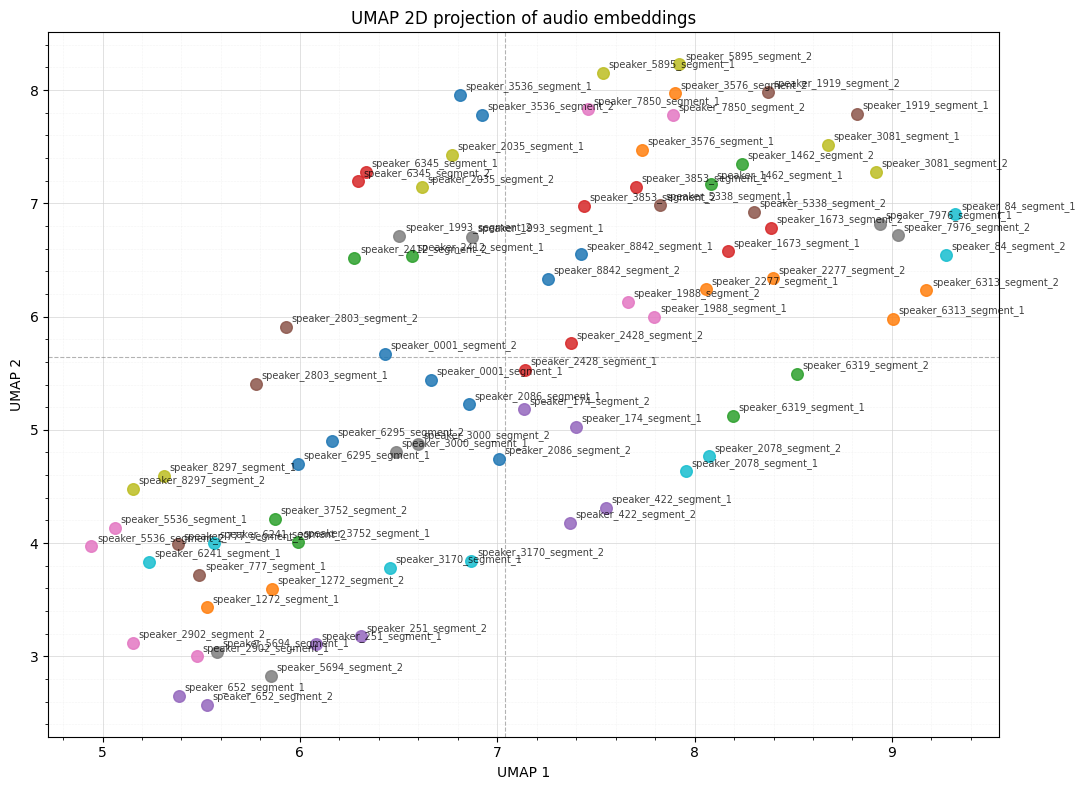

In [57]:
voices_embeddings_df["speaker"] = voices_embeddings_df["audio_filename"].apply(extract_speaker)

X = stack_embeddings(voices_embeddings_df)
coords_2d = compute_umap(X, n_components=2)
voices_embeddings_df[["umap_x", "umap_y"]] = coords_2d

plot_umap_2d(voices_embeddings_df, coords_2d)

### 3D UMAP

In [58]:
pio.renderers.default = "iframe_connected"

coords_3d = compute_umap(X, n_components=3)
fig_3d = plot_umap_3d(voices_embeddings_df, coords_3d)

    n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


## 5. Index

In [59]:
print(f"Index to create: '{INDEX_NAME}'")

Index to create: 'audio-voices-qdrant-index'


### Index definition

In [60]:
voice_emb_length = voice1_emb.shape[0]  # Dimensions of the audio embeddings
print(f"Length of the vector embeddings = {voice_emb_length}")

Length of the vector embeddings = 192


In [61]:
client = get_client(str(QDRANT_PATH))

In [62]:
client

In [63]:
delete_index_if_exists(client, INDEX_NAME)

create_audio_search_index(
    client=client,
    index_name=INDEX_NAME,
    emb_length=EMB_LENGTH,
)

Collection 'audio-voices-qdrant-index' did not exist, nothing to delete.
Collection 'audio-voices-qdrant-index' created with dim=192.


    Payload indexes have no effect in the local Qdrant. Please use server Qdrant if you need payload indexes.


In [64]:
info = client.get_collection(INDEX_NAME)
info

CollectionInfo(status=<CollectionStatus.GREEN: 'green'>, optimizer_status=<OptimizersStatusOneOf.OK: 'ok'>, warnings=None, indexed_vectors_count=0, points_count=0, segments_count=1, config=CollectionConfig(params=CollectionParams(vectors=VectorParams(size=192, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=False, memory=None, datatype=None, multivector_config=None), shard_number=None, sharding_method=None, replication_factor=None, write_consistency_factor=None, read_fan_out_factor=None, read_fan_out_delay_ms=None, on_disk_payload=None, payload=None, sparse_vectors=None), hnsw_config=HnswConfig(m=16, ef_construct=100, full_scan_threshold=10000, max_indexing_threads=0, on_disk=None, memory=None, payload_m=None, inline_storage=None), optimizer_config=OptimizersConfig(deleted_threshold=0.2, vacuum_min_vector_number=1000, default_segment_number=0, max_segment_size=None, memmap_threshold=None, indexing_threshold=20000, flush_interval_sec=5, max_opti

### Documents to load

In [65]:
documents = build_documents(df_samples_1["file_path"].tolist(),
                            category="enrollment")

print(
    f"{len(documents)} documents built, dim={len(documents[0]['audio_embeddings'])}"
)

Embedding:   0%|          | 0/41 [00:00<?, ?it/s]

41 documents built, dim=192


In [66]:
upload_documents_to_index(client, INDEX_NAME, documents)

print(f"\nDocuments in index = {get_index_document_count(client, INDEX_NAME)}")

Uploaded 41 points into 'audio-voices-qdrant-index'.

Documents in index = 41


In [67]:
points, _ = client.scroll(collection_name=INDEX_NAME,
                          limit=5,
                          with_payload=True,
                          with_vectors=False)

for p in points:
    print(p.id, p.payload)

1 {'audio_filename': 'speaker_0001_segment_1.wav', 'audio_filepath': 'voices/speaker_0001_segment_1.wav', 'audio_category': 'enrollment', 'speaker_id': 'speaker_0001'}
2 {'audio_filename': 'speaker_1272_segment_1.wav', 'audio_filepath': 'voices/speaker_1272_segment_1.wav', 'audio_category': 'enrollment', 'speaker_id': 'speaker_1272'}
3 {'audio_filename': 'speaker_1462_segment_1.wav', 'audio_filepath': 'voices/speaker_1462_segment_1.wav', 'audio_category': 'enrollment', 'speaker_id': 'speaker_1462'}
4 {'audio_filename': 'speaker_1673_segment_1.wav', 'audio_filepath': 'voices/speaker_1673_segment_1.wav', 'audio_category': 'enrollment', 'speaker_id': 'speaker_1673'}
5 {'audio_filename': 'speaker_174_segment_1.wav', 'audio_filepath': 'voices/speaker_174_segment_1.wav', 'audio_category': 'enrollment', 'speaker_id': 'speaker_174'}


In [68]:
test_documents = build_documents(df_samples_2["file_path"].tolist(),
                                 category="test")

print(f"{len(test_documents)} test embeddings computed.")

Embedding:   0%|          | 0/41 [00:00<?, ?it/s]

41 test embeddings computed.


### Quick single tests

In [69]:
test_voice = df_samples_2.loc[0, "file_path"]

In [70]:
print(test_voice)
Audio(test_voice)

voices/speaker_0001_segment_2.wav


In [71]:
get_audio_metadata(test_voice)


 -------------------- Audio Statistics -------------------- 

Audio File:	 voices/speaker_0001_segment_2.wav
Modified Date:	 Wed Sep  2 07:40:13 2026
Creation Date:	 Wed Sep  2 07:40:14 2026
File Size:	 160044
Audio Format:	 WAVEAudioFormat.PCM
Bit Depth:	 16
Bit Rate:	 256000
Sampling Rate:	 16000
Nb of Channels:	 1
Duration:	 5.0


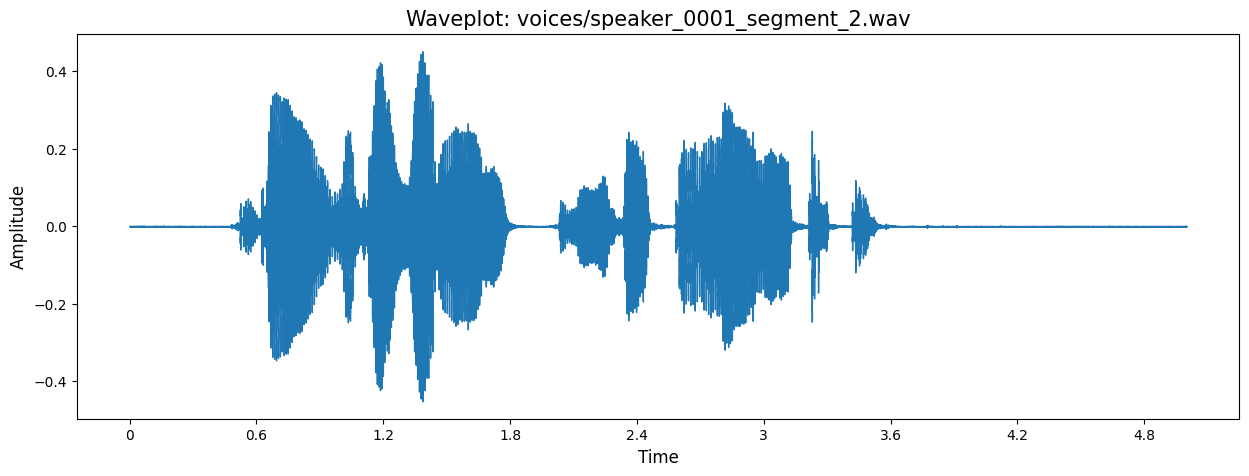

In [72]:
display_amplitude(test_voice)

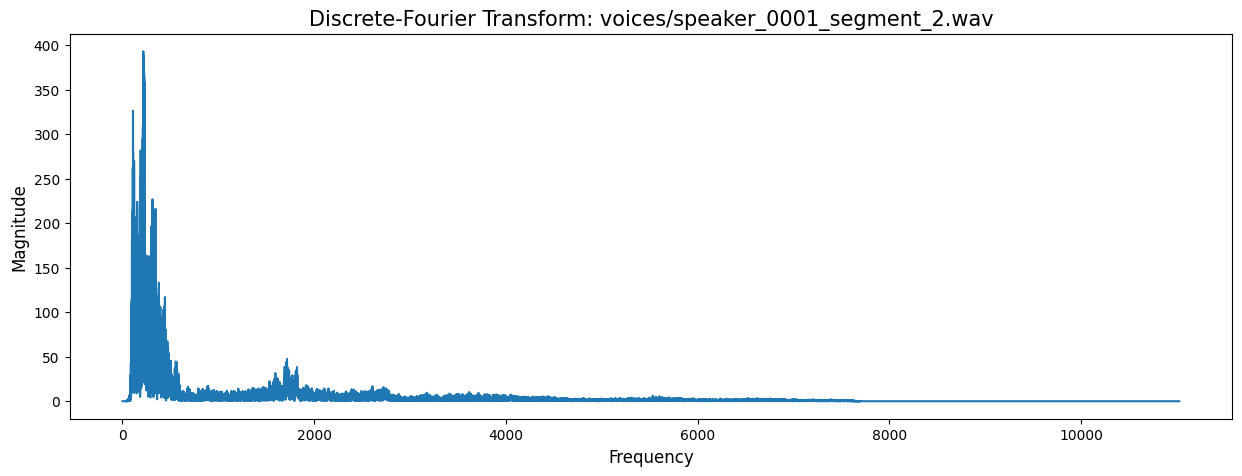

In [73]:
display_fft(test_voice)

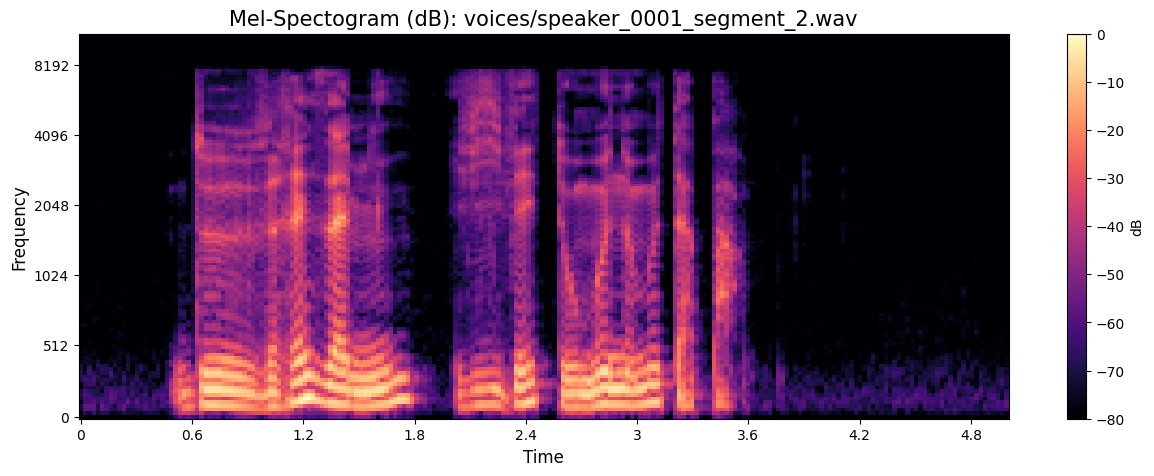

In [74]:
display_mel_spectogram(test_voice)

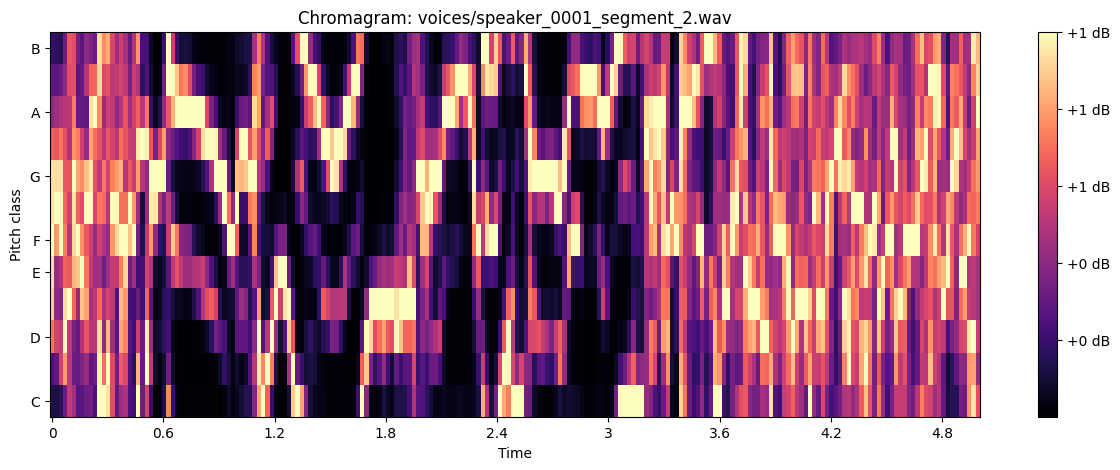

In [75]:
display_chromagram(test_voice)

In [76]:
find_similar_voice(test_documents[0]["audio_embeddings"], topn=5)

    Local mode performs exact (brute-force) search, so `search_params` has no effect, with the exception of `idf`.


,speaker_id,audio_filename,cosine_similarity
0,speaker_0001,speaker_0001_segment_1.wav,0.761349
1,speaker_6295,speaker_6295_segment_1.wav,0.182430
2,speaker_2277,speaker_2277_segment_1.wav,0.172393
3,speaker_2086,speaker_2086_segment_1.wav,0.165244
4,speaker_6319,speaker_6319_segment_1.wav,0.157009


> Speaker 0001 is correctly identified.

In [77]:
test_voice = df_samples_2.loc[20, "file_path"]
print(test_voice)
Audio(test_voice)

voices/speaker_3536_segment_2.wav


In [78]:
get_audio_metadata(test_voice)


 -------------------- Audio Statistics -------------------- 

Audio File:	 voices/speaker_3536_segment_2.wav
Modified Date:	 Wed Sep  2 07:39:48 2026
Creation Date:	 Wed Sep  2 07:40:04 2026
File Size:	 160044
Audio Format:	 WAVEAudioFormat.PCM
Bit Depth:	 16
Bit Rate:	 256000
Sampling Rate:	 16000
Nb of Channels:	 1
Duration:	 5.0


In [79]:
find_similar_voice(test_documents[20]["audio_embeddings"], topn=3)

,speaker_id,audio_filename,cosine_similarity
0,speaker_3536,speaker_3536_segment_1.wav,0.735929
1,speaker_6345,speaker_6345_segment_1.wav,0.250098
2,speaker_7850,speaker_7850_segment_1.wav,0.232556


## All voices 

In [80]:
df = identify_all(test_documents, threshold=0.5)
df

,true_speaker,predicted_speaker,audio_filename,score,runner_up_score,score_gap,accepted,correct,elapsed_time_secs
0,speaker_0001,speaker_0001,speaker_0001_segment_2.wav,0.761349,0.182430,0.578919,True,True,0.000802
1,speaker_1272,speaker_1272,speaker_1272_segment_2.wav,0.810276,0.318377,0.491899,True,True,0.000499
2,speaker_1462,speaker_1462,speaker_1462_segment_2.wav,0.795548,0.419777,0.375771,True,True,0.000458
3,speaker_1673,speaker_1673,speaker_1673_segment_2.wav,0.672702,0.438127,0.234575,True,True,0.000402
4,speaker_174,speaker_174,speaker_174_segment_2.wav,0.755709,0.316643,0.439066,True,True,0.000397
5,speaker_1919,speaker_1919,speaker_1919_segment_2.wav,0.732838,0.271737,0.461101,True,True,0.000379
6,speaker_1988,speaker_1988,speaker_1988_segment_2.wav,0.755143,0.260634,0.494509,True,True,0.000529
7,speaker_1993,speaker_1993,speaker_1993_segment_2.wav,0.738317,0.330853,0.407464,True,True,0.000384
8,speaker_2035,speaker_2035,speaker_2035_segment_2.wav,0.780913,0.287552,0.493361,True,True,0.000384
9,speaker_2078,speaker_2078,speaker_2078_segment_2.wav,0.799367,0.320110,0.479257,True,True,0.000482


In [81]:
n_correct = df["correct"].sum()
n_rejected = (~df["accepted"]).sum()

print(f"Accuracy (accepted only): {n_correct} / {len(df)}")
print(f"Rejected as unknown: {n_rejected}")

Accuracy (accepted only): 41 / 41
Rejected as unknown: 0


> All the speakers were identified

In [82]:
df.describe()

,score,runner_up_score,score_gap,elapsed_time_secs
count,41.000000,41.000000,41.000000,41.000000
mean,0.773508,0.314409,0.459099,0.000403
std,0.058496,0.060599,0.083700,0.000074
min,0.551091,0.171157,0.158991,0.000361
25%,0.755143,0.271737,0.419062,0.000372
50%,0.781532,0.318377,0.461101,0.000381
75%,0.812534,0.358510,0.512172,0.000397
max,0.872831,0.438127,0.591127,0.000802


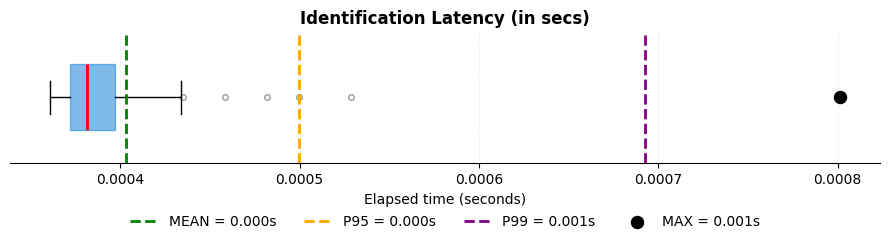

In [83]:
plot_latency(df.elapsed_time_secs)
plt.show()

In [84]:
df["elapsed_time_secs"].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    41.000000
mean      0.000403
std       0.000074
min       0.000361
5%        0.000364
25%       0.000372
50%       0.000381
75%       0.000397
95%       0.000499
99%       0.000692
max       0.000802
Name: elapsed_time_secs, dtype: float64

### Saving predictions into Excel

In [85]:
excel_file = "speakers_predictions_qdrant.xlsx"

df.to_excel(excel_file, index=False)
!ls $excel_file -lh

-rwxrwxrwx 1 root root 8.2K Sep  3 09:59 speakers_predictions_qdrant.xlsx


In [86]:
link = FileLink(path=excel_file)
link

/mnt/batch/tasks/shared/LS_root/mounts/clusters/seretkow1/code/Users/seretkow/voice embeddings/speakers_predictions_qdrant.xlsx

## 6. Post Processing

### Index informations

In [87]:
print_index_summary(client, INDEX_NAME)

Collection name: audio-voices-qdrant-index
Points count:    41
Status:          green

Vector config:
  Dimension: 192
  Distance:  Cosine

HNSW config:
  m:           16
  ef_construct: 100

Quantization: None

Payload indexes: []


In [88]:
info = client.get_collection(INDEX_NAME)
info

CollectionInfo(status=<CollectionStatus.GREEN: 'green'>, optimizer_status=<OptimizersStatusOneOf.OK: 'ok'>, warnings=None, indexed_vectors_count=0, points_count=41, segments_count=1, config=CollectionConfig(params=CollectionParams(vectors=VectorParams(size=192, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=False, memory=None, datatype=None, multivector_config=None), shard_number=None, sharding_method=None, replication_factor=None, write_consistency_factor=None, read_fan_out_factor=None, read_fan_out_delay_ms=None, on_disk_payload=None, payload=None, sparse_vectors=None), hnsw_config=HnswConfig(m=16, ef_construct=100, full_scan_threshold=10000, max_indexing_threads=0, on_disk=None, memory=None, payload_m=None, inline_storage=None), optimizer_config=OptimizersConfig(deleted_threshold=0.2, vacuum_min_vector_number=1000, default_segment_number=0, max_segment_size=None, memmap_threshold=None, indexing_threshold=20000, flush_interval_sec=5, max_opt

In [89]:
client.get_collections()

CollectionsResponse(collections=[CollectionDescription(name='audio-voices-qdrant-index')])

### Deleting the index (optional)

In [90]:
delete_index_if_exists(client, INDEX_NAME)

Existing collection 'audio-voices-qdrant-index' deleted.


In [91]:
client.get_collections()

CollectionsResponse(collections=[])